In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D 
from matplotlib import gridspec
import matplotlib.colors as colors
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib import cm
from matplotlib.patches import Patch

import os
import scanpy as sc

import seaborn as sns
import snapatac2 as snap

snap.__version__


/home/syyang/python_virtuenv/atac_tobias3.13/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


'2.9.0'

## Load Data

In [2]:
entropy_dir = '/mnt/hdd_bob/syy/adipose/atac/res/VIB_10xmultiome_2_WS3000F'
Union_cell_subdir = os.path.join(entropy_dir, '_cell_calling_comparison')
Union_cell_info_file = os.path.join(Union_cell_subdir, 'Union_cell_3set_with_stringent_calling.tsv')
union_cell_info = pd.read_csv(Union_cell_info_file, sep='\t', index_col=0)
union_cell_info['index'] = union_cell_info.index.map(lambda x: x + '-1')

union_cell_info.head(2)

,total_fragments,atac_pass_CR,atac_pass_entropy,atac_pass_archr_TSS,_2set_identified_by_atac_SC,_2set_identified_by_atac_ST,rna_barcodes,rna_pass_CR,Entropy,leiden_RNA_scVI,DNA_debris,_3set_identified_by_atac,P_closed_state,stringent_cell_calling,index
atac_bc,,,,,,,,,,,,,,,
AAACAAGCAAGTTAGT,2412,True,True,True,both,both,GGCTAGTGTGTTAGCA,True,0.218328,3,NO,common,0.965116,True,AAACAAGCAAGTTAGT-1
AAACAAGCATTTCTTC,9030,True,True,True,both,both,GGCTAGTGTACGTTTC,True,0.074451,0,NO,common,0.990949,True,AAACAAGCATTTCTTC-1


In [3]:
nucleosome_info_file = os.path.join(Union_cell_subdir, 'nucleosome_signal_by_cell.csv')
nucleosome_info = pd.read_csv(nucleosome_info_file, index_col=0)
nucleosome_info['index'] = nucleosome_info.index.map(lambda x: x + '-1')
nucleosome_info.head(2)

,nucleosome_signal,index
atac_bc,,
AAACAAGCAAGTTAGT,-1.552972,AAACAAGCAAGTTAGT-1
AAACAAGCATTTCTTC,-1.926050,AAACAAGCATTTCTTC-1


In [4]:
frip_score_file = os.path.join(Union_cell_subdir, 'frip_cells_info.tsv')
frip_score_info = pd.read_csv(frip_score_file, sep='\t', index_col=0)
frip_score_info['index'] = frip_score_info.index.map(lambda x: x + '-1')
frip_score_info.head(2)

,total_fragments,atac_pass_CR,atac_pass_entropy,atac_pass_archr_TSS,_2set_identified_by_atac_SC,_2set_identified_by_atac_ST,rna_barcodes,rna_pass_CR,Entropy,leiden_RNA_scVI,DNA_debris,Nfrag_in_raw_peaks,Nfrag_in_entropy_peaks,Nfrag_in_tss_peaks,Nfrag_in_frip_peaks,FRIP_raw_peaks,FRIP_entropy_peaks,FRIP_tss_peaks,FRIP_frip_peaks,index
atac_bc,,,,,,,,,,,,,,,,,,,,
AAACAAGCAAGTTAGT,2412,True,True,True,both,both,GGCTAGTGTGTTAGCA,True,0.218328,3,NO,1729,1919,1933,1785,71.683250,79.560531,80.140962,74.004975,AAACAAGCAAGTTAGT-1
AAACAAGCATTTCTTC,9030,True,True,True,both,both,GGCTAGTGTACGTTTC,True,0.074451,0,NO,1538,1847,1877,1635,17.032115,20.454042,20.786268,18.106312,AAACAAGCATTTCTTC-1


In [5]:
amulet_doublet_atac_file = os.path.join(Union_cell_subdir, 'AMULET_output/MultipletBarcodes_01.txt')
doublet_atac_barcodes = pd.read_csv(amulet_doublet_atac_file, header=None)
doublet_atac_barcodes.columns = ['barcodes']
doublet_atac_barcodes['atac_bc'] = doublet_atac_barcodes['barcodes'].str.split('-').str[0]
doublet_atac_barcodes.head(2)

,barcodes,atac_bc
0,AAAGCCTAGGATTATG-1,AAAGCCTAGGATTATG
1,AAAGGCGCACTAATCC-1,AAAGGCGCACTAATCC


In [6]:
data_filter = sc.read_h5ad(os.path.join(Union_cell_subdir, '_SNAPataC_analysis', 'binnedGenome_unioncells_filtered.h5ad'))

# filtered_leiden_file = os.path.join(Union_cell_subdir, '_SNAPataC_analysis', 'binnedGenome_unioncells_filtered_obs.csv')
# data_filter.obs[[ 'leiden', 'filtered_leiden']].to_csv(
#     filtered_leiden_file)

In [7]:
data = sc.read_h5ad(os.path.join(Union_cell_subdir, '_SNAPataC_analysis', 'binnedGenome_all_unioncells.h5ad'))

data.obs['filtered_leiden'] = data.obs.index.map(data_filter.obs['filtered_leiden']).fillna('debrisOdoublets')
data.obs['amulet_doublet_atac'] = data.obs.index.isin(doublet_atac_barcodes['barcodes'])

data.obs['debris_doublets_flag'] = data.obs.apply(lambda row: 
    'debrisNdoublet' if row['DNA_debris'] == 'YES' and row['amulet_doublet_atac'] == True \
        else ('doublets' if row['amulet_doublet_atac'] == True \
            else ('Debris' if row['DNA_debris'] == 'YES' else 'clean')), axis=1)


# Vis

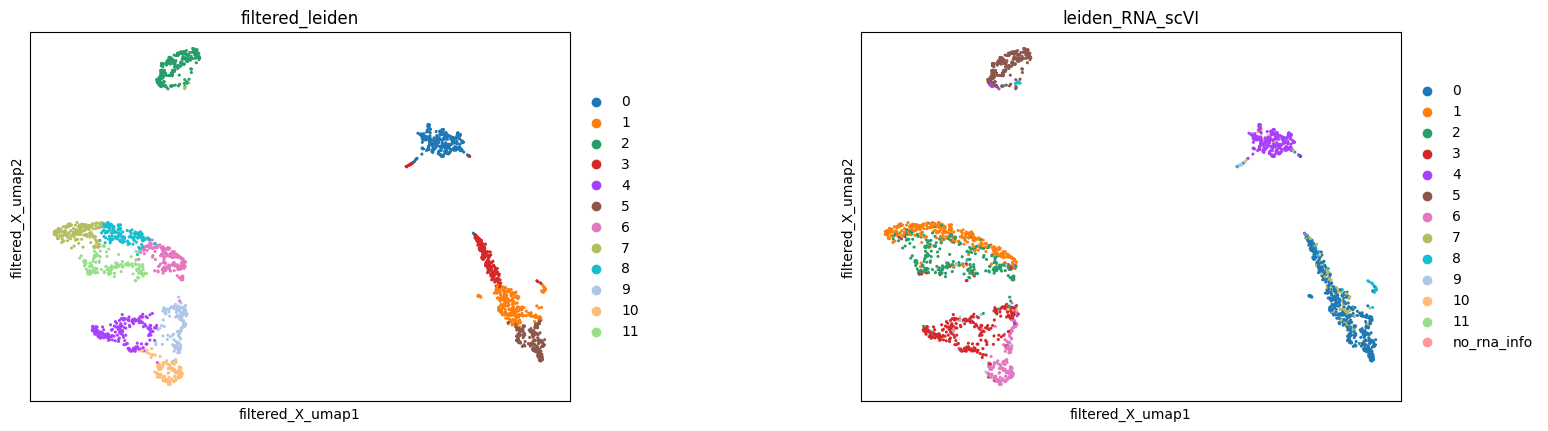

In [8]:
sc.pl.embedding(data_filter, basis='filtered_X_umap', color=['filtered_leiden',  'leiden_RNA_scVI', ], s=20, ncols=2, wspace=0.4)

# Call Peaks with MACS3 
MACS3 peak-calling on ATAC-seq really is not good

In [9]:
snap.tl.macs3(data,  key_added='union_macs3', n_jobs=30)

2026-04-27 13:25:12 - INFO - [5763 MB] #3 Pre-compute pvalue-qvalue table...
2026-04-27 13:29:36 - INFO - [5763 MB] #3 Call peaks for each chromosome...


In [17]:
snap.tl.macs3(data, groupby='rna_pass_CR', key_added='rna_pass_CR_macs3', n_jobs=30)

2026-04-27 13:52:01 - INFO - Exporting fragments...
2026-04-27 13:52:16 - INFO - Calling peaks...
100%|██████████| 2/2 [05:11<00:00, 155.80s/it]


In [19]:
snap.tl.macs3(data, groupby='debris_doublets_flag', key_added='debris_doublets_flag_macs3', n_jobs=30)

2026-04-27 15:33:58 - INFO - Exporting fragments...
2026-04-27 15:34:11 - INFO - Calling peaks...
100%|██████████| 4/4 [03:04<00:00, 46.14s/it]


In [ ]:
snap.tl.macs3(data, groupby='filtered_leiden', key_added='filtered_leiden_macs3', n_jobs=30)

2026-04-27 13:36:24 - INFO - Exporting fragments...
2026-04-27 13:36:37 - INFO - Calling peaks...
100%|██████████| 13/13 [04:12<00:00, 19.39s/it]


In [22]:
snap.tl.macs3(data, groupby='atac_pass_entropy', key_added='atac_pass_entropy_macs3', n_jobs=30)

2026-04-27 15:44:04 - INFO - Exporting fragments...
2026-04-27 15:44:18 - INFO - Calling peaks...
100%|██████████| 2/2 [03:09<00:00, 94.79s/it] 


In [25]:
snap.tl.macs3(data, groupby='atac_pass_CR', key_added='atac_pass_CR_macs3', n_jobs=30)

2026-04-27 15:52:32 - INFO - Exporting fragments...
2026-04-27 15:52:47 - INFO - Calling peaks...
100%|██████████| 2/2 [06:04<00:00, 182.32s/it]


In [24]:
snap.tl.macs3(data, groupby='atac_pass_archr_TSS', key_added='atac_pass_archr_TSS_macs3', n_jobs=30)

2026-04-27 15:48:47 - INFO - Exporting fragments...
2026-04-27 15:48:59 - INFO - Calling peaks...
100%|██████████| 2/2 [03:32<00:00, 106.04s/it]


In [26]:
for pset in data.uns['atac_pass_CR_macs3'].keys():
    print(pset, '--', data.uns['atac_pass_CR_macs3'][pset].shape)

False -- (28769, 10)
True -- (107244, 10)


In [27]:
for pset in data.uns['atac_pass_archr_TSS_macs3'].keys():
    print(pset, '--', data.uns['atac_pass_archr_TSS_macs3'][pset].shape)

False -- (19999, 10)
True -- (109092, 10)


In [23]:
for pset in data.uns['atac_pass_entropy_macs3'].keys():
    print(pset, '--', data.uns['atac_pass_entropy_macs3'][pset].shape)

True -- (112256, 10)
False -- (9096, 10)


In [20]:
for pset in data.uns['debris_doublets_flag_macs3'].keys():
    print(pset, '--', data.uns['debris_doublets_flag_macs3'][pset].shape)

Debris -- (7, 10)
debrisNdoublet -- (5904, 10)
clean -- (109310, 10)
doublets -- (51946, 10)


In [18]:
for pset in data.uns['rna_pass_CR_macs3'].keys():
    print(pset, '--', data.uns['rna_pass_CR_macs3'][pset].shape)

True -- (105059, 10)
False -- (10309, 10)


In [16]:
for pset in data.uns['filtered_leiden_macs3'].keys():
    print(pset, '--', data.uns['filtered_leiden_macs3'][pset].shape)

6 -- (18629, 10)
11 -- (34235, 10)
2 -- (44058, 10)
4 -- (44342, 10)
5 -- (71912, 10)
3 -- (37615, 10)
7 -- (45892, 10)
8 -- (31009, 10)
9 -- (21834, 10)
10 -- (42705, 10)
debrisOdoublets -- (45892, 10)
1 -- (65729, 10)
0 -- (2928, 10)


In [21]:
data.uns['union_macs3_pseudobulk'].shape

(104060, 10)